In [1]:
# ---------- Setup ----------
%load_ext autoreload
%autoreload 2
import sys, os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Verify that SimpleArm is in the path
SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
if SIMPLEARM_PATH not in sys.path:
    sys.path.insert(0, SIMPLEARM_PATH)

from simplearm.robot import RobotInfo

# Import local functions
import models
from data_shapes import generate_dataset, print_dataset_stats, browse_dataset, visualize_environment
from losses import compute_trajectory_collision_cost, compute_trajectory_joint_limits_cost
from utils import get_world_spheres_torch, query_sdf_differentiable
from training import train, train_env_autoencoder, train_state_autoencoder
from visualization_shapes import browse_trajectories

# Robot configuration
WORKSPACE_RADIUS = 1.0
LINK_LENGTHS = [0.35, 0.45, 0.2]
SPHERE_RAD = 0.08
GRID_LENGTH = 2.5
N_VOX = 128
T = 50  # Time steps in the trajectory
C = 10  # Control points in the spline
Q_MIN = np.array([-np.pi*0.9, -np.pi*0.9, -np.pi*0.9])
Q_MAX = np.array([np.pi*0.9, np.pi*0.9, np.pi*0.9])

robot = RobotInfo.from_linklengths(LINK_LENGTHS, sphere_rad=SPHERE_RAD)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Setup done. Executed in GPU: {gpu_name}")
else:
    print("Setup done. WARNING: Running on CPU. GPU not detected.")

Setup done. Executed in GPU: Tesla T4


Generating SDFs...


Generating SDF dataset:   0%|          | 0/20000 [00:00<?, ?it/s]

SDF dataset saved: data/sdf_dataset_shapes_1707.pt  shape=(20000, 1, 128, 128)


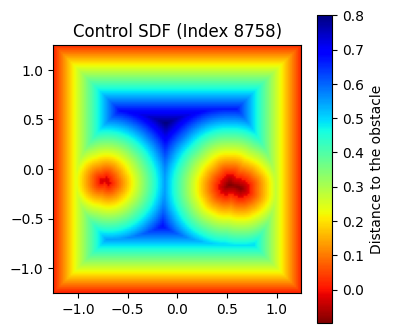

In [5]:
# ---------- SDF Dataset ----------
from data_shapes import generate_sdf_dataset

# Generate 20,000 environments for training the Autoencoder 
print("Generating SDFs...")
sdf_dataset = generate_sdf_dataset(N=20000, save_path="data/sdf_dataset_shapes_1707.pt", seed=42)

# Visual control
idx = torch.randint(0, len(sdf_dataset), (1,)).item()
plt.figure(figsize=(4, 4))
plt.imshow(sdf_dataset[idx, 0].cpu().numpy(), cmap="jet_r", origin="lower", 
           extent=[-GRID_LENGTH/2, GRID_LENGTH/2, -GRID_LENGTH/2, GRID_LENGTH/2])
plt.title(f"Control SDF (Index {idx})")
plt.colorbar(label="Distance to the obstacle")
plt.show()

Training the Environment Autoencoder...


Training Env Autoencoder:   0%|          | 0/8000 [00:00<?, ?it/s]

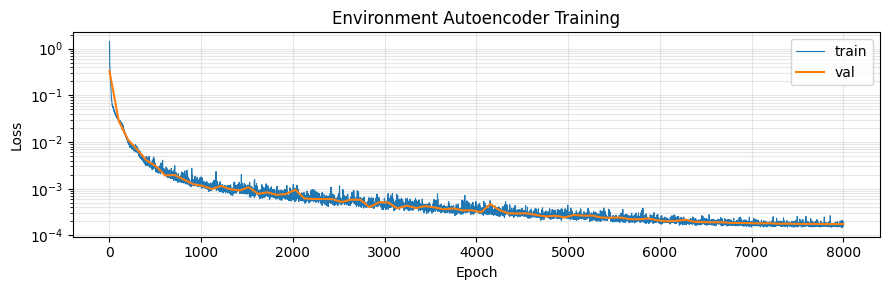

Test loss: 0.000176
Saved: data/env_autoencoder_shapes_1707.pt  (encoder -> data/env_encoder_shapes_1707.pt)
Weights saved in 'data/env_autoencoder_shapes_1707.pt'


In [6]:
# ---------- Environment Autoencoder Training ----------
print("Training the Environment Autoencoder...")

env_model, env_history = train_env_autoencoder(
    dataset_path = "data/sdf_dataset_shapes_1707.pt",
    file_name = "env_encoder_shapes_1707.pt",
    latent_dim   = 64,
    batch_size   = 128,                           
    epochs       = 8000,                          
    lr           = 1e-3,
    log_every    = 100,
    device       = device,
    save_path    = "data/env_autoencoder_shapes_1707.pt" 
)

print("Weights saved in 'data/env_autoencoder_shapes_1707.pt'")

Training State Autoencoder:   0%|          | 0/8000 [00:00<?, ?it/s]

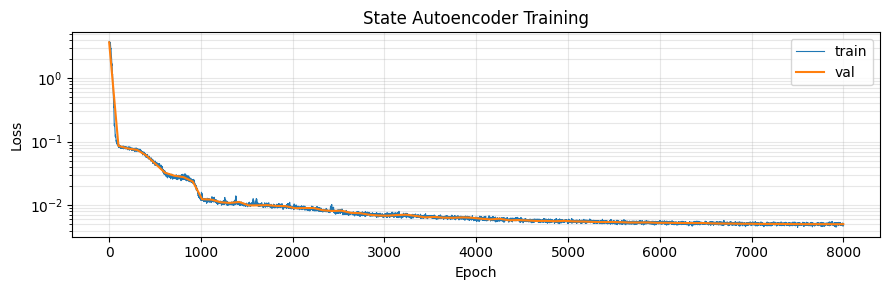

Test loss: 0.005048
Saved: data/state_autoencoder_shapes_1707.pt  (encoder -> data/state_encoder_shapes_1707.pt)
Weights saved in 'data/state_autoencoder_shapes_1707.pt'


In [7]:
# ---------- State Autoencoder Training ----------
from training import train_state_autoencoder
state_ae, state_ae_history = train_state_autoencoder(
    file_name   = "state_encoder_shapes_1707.pt",
    linklengths = LINK_LENGTHS,
    dof         = 3,
    latent_dim  = 12,
    N           = 240_000,
    batch_size  = 256,
    epochs      = 8000,
    lr          = 1e-3,
    log_every   = 100,
    device      = device,
    save_path   = "data/state_autoencoder_shapes_1707.pt"
)

print("Weights saved in 'data/state_autoencoder_shapes_1707.pt'")

In [ ]:
#---------- Dataset generation ----------
SEED = 42

dataset_general_shapes_1707 = generate_dataset(
        N_envs                 = 1000,
        pairs_per_env          = 10,
        robot                  = robot,
        sphere_rad             = SPHERE_RAD,
        q_min                  = Q_MIN,
        q_max                  = Q_MAX,
        
        n_obstacles_range      = (2, 4),    
        r_range                = (0.15, 0.30),
        
        workspace_radius       = WORKSPACE_RADIUS, 
        dist_from_origin       = (0.35, WORKSPACE_RADIUS),
        require_nontrivial     = True,
        grid_length            = GRID_LENGTH,
        n_vox                  = N_VOX,
        seed                   = SEED,
        save_path              = "data/dataset_general_shapes_1707.pt",
        split                  = (0.7, 0.15, 0.15)
)

Generating dataset (Organic Blobs):   0%|          | 0/1000 [00:00<?, ?it/s]


────────────────────────────────────────────────
  Attempts:           10000
  No valid pair:      0
  Successful samples: 10000  (100.0%)
────────────────────────────────────────────────
  Saved: data/dataset_general_shapes_1707_train.pt  (7000 samples, 918.1 MB)
  Saved: data/dataset_general_shapes_1707_val.pt  (1500 samples, 196.7 MB)
  Saved: data/dataset_general_shapes_1707_test.pt  (1500 samples, 196.7 MB)


In [3]:
# ---------- Datasets analysis ----------
print("=== DATASETS - GENERAL STATISTICS ===")

print("\n1. General Dataset:")
print_dataset_stats("data/dataset_general_shapes_1707_train.pt")

print("\n" + "="*20 + " INTERACTIVE VISUALIZATION " + "="*20 + "\n")
interactive_dataset = torch.load("data/dataset_general_shapes_1707_train.pt", weights_only=False)
browse_dataset(interactive_dataset, grid_length=GRID_LENGTH)

=== DATASETS - GENERAL STATISTICS ===

1. General Dataset:
Dataset: 7000 samples
  sdf          (7000, 1, 128, 128)
  q_start      (7000, 3)
  q_goal       (7000, 3)
  voxels       (7000, 1, 128, 128)
  obstacles    (7000, 4, 3)
  n_obstacles  (7000,)

Metadata: {'N': 7000, 'grid_length': 2.5, 'n_vox': 128, 'dof': 3, 'linklengths': [np.float64(0.35), np.float64(0.45), np.float64(0.2)], 'sphere_rad': 0.08, 'workspace_radius': 1.0, 'q_min': [-2.827433388230814, -2.827433388230814, -2.827433388230814], 'q_max': [2.827433388230814, 2.827433388230814, 2.827433388230814]}

Start-config collision rate (first 100 samples): mean=0.000  (should be ~0.0)

==================== INTERACTIVE VISUALIZATION ====================



Starting training...
Loaded env encoder:   data/env_encoder_shapes_1707.pt
Loaded state encoder: data/state_encoder_shapes_1707.pt

Loss              Raw      Weight    Weighted
──────────────────────────────────────────────
coll           6.5653    400.0000   2626.1230
joints         0.0000      1.0000      0.0000
smooth         0.2035      1.0000      0.2035
spacing        0.0000      2.0000      0.0000
explore        0.3203      5.0000      1.6016



Training:   0%|          | 0/4000 [00:00<?, ?it/s]

Epoch   200 | lr=4.97e-04 | train=55.9509  coll=55.5346  joints=0.0008  smooth=0.2761  spacing=0.0314  explore=0.1080  val=56.0870
Epoch   400 | lr=4.88e-04 | train=43.7136  coll=42.0487  joints=1.0050  smooth=0.4409  spacing=0.0929  explore=0.1262  val=45.6491
Epoch   600 | lr=4.73e-04 | train=39.5982  coll=37.7565  joints=1.2308  smooth=0.5180  spacing=0.0928  explore=0.0000  val=42.6975
Epoch   800 | lr=4.52e-04 | train=43.1882  coll=40.7344  joints=1.6596  smooth=0.5762  spacing=0.1026  explore=0.1153  val=39.4585
Epoch  1000 | lr=4.27e-04 | train=33.8773  coll=32.0303  joints=1.0229  smooth=0.6625  spacing=0.1312  explore=0.0304  val=35.3514
Epoch  1200 | lr=3.97e-04 | train=25.6374  coll=23.8518  joints=0.7667  smooth=0.8083  spacing=0.1689  explore=0.0417  val=31.0008
Epoch  1400 | lr=3.64e-04 | train=25.8167  coll=24.4188  joints=0.3793  smooth=0.8372  spacing=0.1814  explore=0.0000  val=28.0931
Epoch  1600 | lr=3.28e-04 | train=22.2239  coll=20.7955  joints=0.4033  smooth=0.82

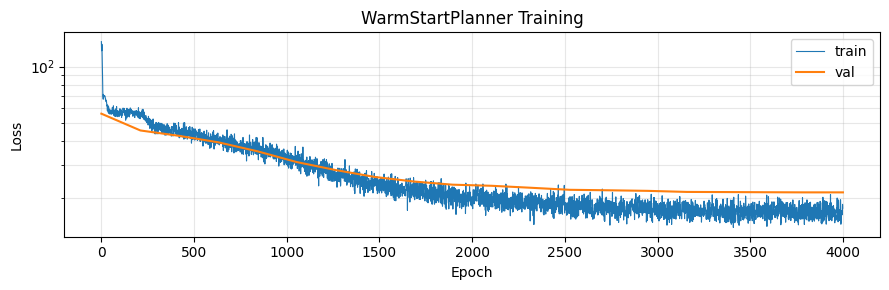

Model saved: models/wsp_general_shapes_1707_v1.pt


In [4]:
# ---------- WarmStartPlanner SSL Training ----------
# Full dataset with new shapes - 17/07
print("Starting training...")
    
model_general_1707_v1, history_general_1707_v1 = train(
    # Paths
    train_dataset       = "data/dataset_general_shapes_1707_train.pt",
    val_dataset         = "data/dataset_general_shapes_1707_val.pt",
        
    # Configuration
    T                   = 50,
    C                   = 10,
        
    # Pre-trained encoders
    env_encoder_path    = "data/env_encoder_shapes_1707.pt",
    state_encoder_path  = "data/state_encoder_shapes_1707.pt",
    freeze_encoders     = True,
        
    # Parameters
    n_epochs            = 4000,
    batch_size          = 128,
    lr                  = 5e-4,
        
    # Loss weights
    w_coll              = 400.0,
    w_joints            = 1.0,
    w_smooth            = 1.0,
    w_spacing           = 2.0,
    w_explore           = 5.0,
        
    # Collision parameters
    explore_threshold   = 0.5,
    collision_eps       = 0.15,
    dt                  = 0.1,
        
    # Monitoring and Hardware
    log_every           = 200,
    device              = "cuda",
    save_path           = "models/wsp_general_shapes_1707_v1.pt",
)

In [2]:
# ---------- Trajectory Visualization ----------
print("Loading model and dataset...")

# Load the model
model_general = torch.load("models/wsp_general_shapes_1707_v1.pt", weights_only=False)
    
# Launch the visualizator
browse_trajectories(
    model     = model_general,
    dataset   = "data/dataset_general_shapes_1707_test.pt",
    save_name = "wsp_working_shapes_1707_v1"
)

Loading model and dataset...
